# In this model we want to do the following:
- Model the white light curve for both visits
- Use fit results to fix the ramp and breathing parameters

In [1]:
from preamble_jax import *

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]


2025-12-12 17:30:06,963 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch
/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/chromatic/imports.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import copy, pkg_resources, os, glob, pickle


🌈🤖 It looks like you're trying to bin in wavelength for a
`Rainbow` object that might not be normalized. In the
current version of `chromatic`, binning before normalizing
might give inaccurate results if the typical uncertainty
varies strongly with wavelength.

Please consider normalizing first, for example with
`rainbow.normalize().bin(...)`
so that all uncertainties will effectively be relative,
and the inverse variance weighting used for binning
wavelengths together will give more reasonable answers.

If you really need to bin before normalizing, please submit
an Issue at github.com/zkbt/chromatic/, and we'll try to
prioritize implementing a statistically sound solution as
soon as possible!



  0%|          | 0/162 [00:00<?, ?it/s]

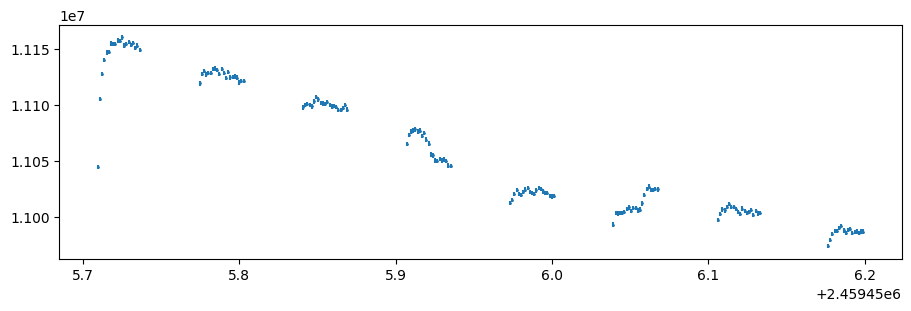

<Figure size 640x480 with 0 Axes>

In [2]:
visit = 'F21'

orbits_to_exclude = np.array([0,1,2,7])
speclc_bin_edges = ([1.14064	,
    1.17700,
    1.1941,
    1.2112,
    1.229,
    1.246,
    1.2649,
    1.32596,
    1.34884667,
    1.39082,
    1.42325,
    1.43715	,
    1.48348	,
    1.53444	,
    1.55297	,
    1.5685,
    1.5925	,
    1.6165,
    1.64050	]) * u.micron
# F21_speclc_bin_edges if visit=='F21' else S22_speclc_bin_edges
# speclc_err_factor = F21_speclc_err_factor if visit=='F21' else S22_speclc_err_factor
# SED_err_factor = F21_SED_err_factor if visit=='F21' else S22_SED_err_factor

predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
_rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
rainbow = _rainbow
# for i in range(len(_rainbow.wavelength.value)):
#     rainbow.uncertainty[i,:] = _rainbow.uncertainty[i,:] * SED_err_factor[i]
speclc_rainbow = rainbow.bin(wavelength_edges = speclc_bin_edges)
# for i in range(len(speclc_rainbow.wavelength)):
#     speclc_rainbow.uncertainty[i,:] = speclc_rainbow.uncertainty[i,:] * speclc_err_factor[i]

# trim_spots = ( _speclc_rainbow.mask_transit(period=8.463*u.day, t0=(predicted_T0+0.027)*u.day, duration=0.075*u.day).trim() )

# trim_spots.imshow()
# plt.show()
# plt.clf()

# speclc_rainbow = trim_spots.trim()
# speclc_rainbow.time = speclc_rainbow.time + (predicted_T0+0.027)*u.day

# Check a light curve to verify the spots are getting trimmed
plt.figure(figsize=(9,3))
plt.errorbar(speclc_rainbow.time,speclc_rainbow.flux[10,:],speclc_rainbow.uncertainty[10,:],
            fmt='o',ms=1)
plt.show()
plt.clf()

Median relative photon uncertainty at 1.1588 micron = 123ppm
Median relative photon uncertainty at 1.1856 micron = 173ppm
Median relative photon uncertainty at 1.2026 micron = 170ppm
Median relative photon uncertainty at 1.2201 micron = 163ppm
Median relative photon uncertainty at 1.2375 micron = 164ppm
Median relative photon uncertainty at 1.2554 micron = 155ppm
Median relative photon uncertainty at 1.2954 micron = 84ppm
Median relative photon uncertainty at 1.3374 micron = 135ppm
Median relative photon uncertainty at 1.3698 micron = 100ppm
Median relative photon uncertainty at 1.4070 micron = 115ppm
Median relative photon uncertainty at 1.4302 micron = 175ppm
Median relative photon uncertainty at 1.4603 micron = 96ppm
Median relative photon uncertainty at 1.5090 micron = 91ppm
Median relative photon uncertainty at 1.5437 micron = 152ppm
Median relative photon uncertainty at 1.5607 micron = 166ppm
Median relative photon uncertainty at 1.5805 micron = 135ppm
Median relative photon unce

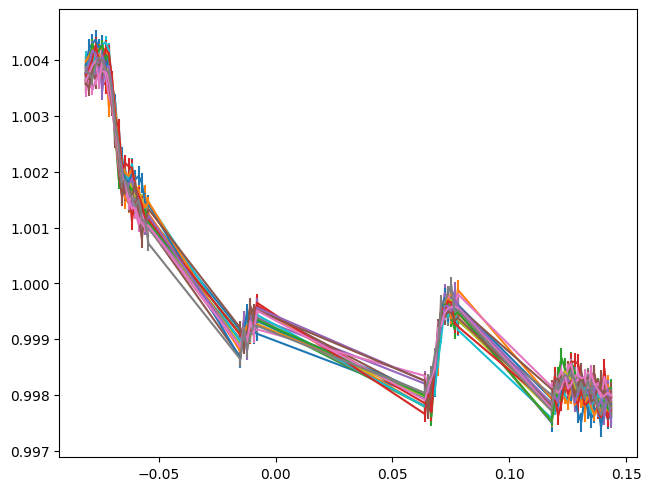

In [3]:
data_wavelengths = speclc_rainbow.wavelength.value
img_date = speclc_rainbow.time.value
data_flux = speclc_rainbow.flux.value
relative_err = speclc_rainbow.uncertainty.value/data_flux
time_from_T0 = img_date - predicted_T0

for i in range(len(data_wavelengths)):
    print(f'Median relative photon uncertainty at {data_wavelengths[i]:.4f} micron = {int(np.nanmedian(relative_err[i,:])*1e6)}ppm')

_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=data_wavelengths)['y'] * u.cm**2 / u.erg

for i,date in enumerate(img_date):
    e_per_s = data_flux[:,i] / exptime
    e_per_s_per_angstrom = e_per_s / binwidth
    calibrated_flux = (e_per_s_per_angstrom.flatten() / binned_filter_response)
    data_flux[:,i] = calibrated_flux.value

# Label the orbits
orbit = np.zeros_like(img_date)
for j in range(len(img_date)):
    if j >= 1:
        if (img_date[j] - img_date[j - 1]) > 0.01:
            orbit[j] = (orbit[j - 1] + 1)
        else:
            orbit[j] = orbit[j - 1]

# Trim the first point from each orbit
ref_time = []
for o in np.unique(orbit):
    first_index = np.where(orbit == o)[0][0]
    ref_time.append(img_date[first_index])
    data_flux[:, first_index] = np.nan  # Set the first point of each subsequent orbit to np.nan
    relative_err[:, first_index] = np.nan
    img_date[first_index] = np.nan
    time_from_T0[first_index] = np.nan

time_from_T0[90:114] = np.nan

# Set data to nan if it was in the pre-defined list of orbits to exclude
for orbit_to_exclude in orbits_to_exclude:
    data_flux[:, orbit == orbit_to_exclude] = np.nan
    relative_err[:, orbit == orbit_to_exclude] = np.nan
    img_date[orbit == orbit_to_exclude] = np.nan
    time_from_T0[orbit == orbit_to_exclude] = np.nan

# Populate ramp_phase time arrays
phase_list=[]
for o in [0,1,2,3,4,5,6,7]:
    rphase = (img_date[orbit==o] - ref_time[o]) / 0.066
    phase_list.append(rphase)
ramp_phase = np.concatenate(phase_list)
breathing_phase = ( (img_date-ref_time[0]+0.02) / 0.066 ) % 1

# Convert all arrays to JAX arrays

data_flux = jnp.array( data_flux[:,~np.isnan(time_from_T0)] )
_relative_err = jnp.array(relative_err[:,~np.isnan(time_from_T0)] )
img_date = jnp.array(img_date[~np.isnan(time_from_T0)] )
# ramp_phase = jnp.array(ramp_phase[~np.isnan(ramp_phase)] )
ramp_phase = jnp.array(ramp_phase[~np.isnan(time_from_T0)] )
# breathing_phase = jnp.array(breathing_phase[~np.isnan(breathing_phase)] )
breathing_phase = jnp.array(breathing_phase[~np.isnan(time_from_T0)] )

time_from_T0 = jnp.array(time_from_T0[~np.isnan(time_from_T0)] )

mean_per_wavelength = jnp.mean(data_flux, axis=1, keepdims=True)
normalized_data_flux = data_flux / mean_per_wavelength
relative_err = _relative_err * normalized_data_flux
jax_rel_err = relative_err
jax_flux = normalized_data_flux

planet_parameters = dict(
    inclination = jnp.radians(89.5),
    a = 19.15,
    rp = 0.047,
    period = 8.46,
    t0 = 0,
    ecc = 0.0,
    u1 = 0.25,
    u2 = 0.15)

# initial_lons = jnp.array(np.random.uniform(-2.8,2.8,n_spots))
# jnp.save('../data/initial_lons',initial_lons)
# initial_lats = jnp.array(random.choice( [np.random.beta(2, 1,n_spots)*(1.25 - 0.2) + 0.2, np.random.beta(1,2,n_spots)*(3.0 - 2.0) + 2.0 ]))
# jnp.save('../data/initial_lats',initial_lats)
# initial_radii = jnp.array([0.005]*n_spots)

for i in range(len(data_wavelengths)):
    plt.errorbar(time_from_T0, normalized_data_flux[i,:], relative_err[i,:])

In [ ]:
default_params={

    # Ramp Model Parameters
    'r_1': 12.67,
    'r_2': -6.7,
    'r_3': 0.0135,
    #Breathing params
    'b_1':-0.024,
    'b_2':0.066,
    'b_3':-0.059,
    'b_4':0.018,

    'baseline_slope':0,
    
    # Planet parameters
    'Mp':8.0,
    'i_planet':89.5,
    'P_orb':8.463,
    't_0':0.00025,
    'rp_rstar': 0.0465,
    'a_rstar': 19.10,
    'ecc': 0.0,
    'u_1':0.35,
    'u_2':0.15,
    
    # Stellar parameters
    'log_g':4.5,
    'i_star':89.5,
    'P_rot':4.86,
    'Rs':0.8,
    'Ms':0.6,
    'metallicity':0.0,

    # Spot Parameters
    'log_fixedspot_radii':-1.6,
    'T_unocculted': 3100,
    'T_occulted': 3500,
    'T_phot': 4200,
    'T_spot': 3550,
    'limb_spot_lon':0,#-1.305,
    'limb_spot_lat':0,#1.2,
    'limb_spot_rad':0,#0.22,
    'chord_spot_lon_1':0,#0.05,
    'chord_spot_lat_1':0,#1.54,
    'chord_spot_rad_1':0,#0.15,
    'chord_spot_lon_2':0,#0.86,
    'chord_spot_lat_2':0,#1.66,
    'chord_spot_rad_2':0,#0.055,

    # Model meta-parameters
    'beta':0.25,

}

In [4]:
def numpyro_model():

    """
    Define the probabilistic model in NUMPYRO
    """
    params = {}

    # Instrument Parameters
    params['r_1'] = 12.67 #numpyro.sample('r_1', dist.Uniform(1.0, 30.0))
    params['r_2'] = numpyro.sample('r_2', dist.Uniform(-9.0, -4.0))
    params['r_3'] = numpyro.sample('r_3', dist.Uniform(-0.01,0.01))

    # Instrument Parameters
    params['b_1'] = -0.024
    params['b_2'] = 0.066
    params['b_3'] = -0.059
    params['b_4'] = 0.018

    # Baseline Parameters
    params['baseline_slope'] = numpyro.sample('baseline_slope', dist.Uniform(-0.04, -0.01))
    
    # Planet Parameters
    params['rp_rstar'] = numpyro.sample('rp_rstar', dist.Uniform(0.04, 0.056))
    params['t_0'] = 0.00025
    params['a_rstar'] = 19.10
    
    params['u_1'] = numpyro.sample('u_1', dist.Uniform(0.0,0.55))
    params['u_2'] = numpyro.sample('u_2', dist.Uniform(0.0,0.55))
    
    params['beta'] = numpyro.sample('beta', dist.Uniform(0.0,0.1))
    
    @jit
    def broadband_transit(params,**kwargs):

         # Calculate systematics model
        ramp = ramp_model_jax(phase=ramp_phase,
                        r1=jnp.asarray(params['r_1'], dtype=jnp.float64),
                        r2=jnp.asarray(params['r_2'], dtype=jnp.float64),
                        r3=jnp.asarray(params['r_3'], dtype=jnp.float64) )
        breathing = breathing_model_jax(phase=breathing_phase,
                                  b1=jnp.asarray(params['b_1'], dtype=jnp.float64),
                                  b2=jnp.asarray(params['b_2'], dtype=jnp.float64),
                                  b3=jnp.asarray(params['b_3'], dtype=jnp.float64),
                                  b4=jnp.asarray(params['b_4'], dtype=jnp.float64))
        linear_baseline = linear_model_jax(x=time_from_T0,
                                            m=jnp.asarray(params['baseline_slope'], dtype=jnp.float64),
                                            )
        _systematics = (breathing * ramp * linear_baseline)
        systematics = _systematics/jnp.mean(_systematics)
        
        # Update Planet Parameters
        planet_parameters = dict(
            inclination = jnp.radians(default_params['i_planet']),
            a = jnp.asarray(params['a_rstar'], dtype=jnp.float64),
            rp = jnp.asarray(params['rp_rstar'], dtype=jnp.float64),
            period = default_params['P_orb'],
            t0 = jnp.asarray(params['t_0'], dtype=jnp.float64),
            ecc = default_params['ecc'],
            u1 = jnp.asarray(params['u_1'], dtype=jnp.float64),
            u2 = jnp.asarray(params['u_2'], dtype=jnp.float64)
        )
        
        # Get spectra for the model temps
        Phot = get_binned_BTSettl_spectrum_jax(T=4200,data_wave = data_wavelengths)
        Cool = get_binned_BTSettl_spectrum_jax(T=3550,data_wave = data_wavelengths)
        
        # Update stellar parameters
        active_star = ActiveStar(
        times = time_from_T0,
        inclination=jnp.radians(89.5),
        T_eff=jnp.asarray(4200, dtype=jnp.float64),
        wavelength=Phot[0]*1e-6, # m
        phot=Phot[1],
        P_rot=4.863)
        
        active_star.spectrum = Cool[1]
        active_star.temperature = jnp.array([3550])
        active_star.lon = jnp.array([0])
        active_star.lat = jnp.array([0])
        active_star.rad = jnp.array([0])  
        
        lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)        
        lc_model = lc.T[lc_index] * systematics
        mean_per_wavelength = jnp.mean(lc_model)
        normalized_model = lc_model / mean_per_wavelength
    
        return normalized_model

    numpyro.sample(
        "Obs", dist.Normal(
            loc=broadband_transit(params), 
            scale=(10**jnp.asarray(params['beta'], dtype=jnp.float64))*data_unc,
        ), obs=relative_flux
    )

In [5]:
def plot_results(parameter_dict,
                 figlabel='missinglabel'):
    
    params = parameter_dict

    # Calculate systematics model
    ramp = ramp_model_jax(phase=ramp_phase,
                    r1=jnp.asarray(params.get('r_1',default_params['r_1']), dtype=jnp.float64),
                    r2=jnp.asarray(params.get('r_2',default_params['r_2']), dtype=jnp.float64),
                    r3=jnp.asarray(params.get('r_3',default_params['r_3']), dtype=jnp.float64) )
    breathing = breathing_model_jax(phase=breathing_phase,
                              b1=jnp.asarray(params.get('b_1',default_params['b_1']), dtype=jnp.float64),
                              b2=jnp.asarray(params.get('b_2',default_params['b_2']), dtype=jnp.float64),
                              b3=jnp.asarray(params.get('b_3',default_params['b_3']), dtype=jnp.float64),
                              b4=jnp.asarray(params.get('b_4',default_params['b_4']), dtype=jnp.float64))
    linear_baseline = linear_model_jax(x=time_from_T0,
                                        m=jnp.asarray(params.get('baseline_slope',default_params['baseline_slope']), dtype=jnp.float64),
                                        )
    _systematics = (breathing * ramp * linear_baseline)
    systematics = _systematics/jnp.mean(_systematics)
    
    # Update Planet Parameters
    planet_parameters = dict(
        inclination = jnp.radians(default_params['i_planet']),
        a = jnp.asarray(params.get('a_rstar',default_params['a_rstar']), dtype=jnp.float64),
        rp = jnp.asarray(params.get('rp_rstar',default_params['rp_rstar']), dtype=jnp.float64),
        period = jnp.asarray(params.get('P_orb',default_params['P_orb']), dtype=jnp.float64),
        t0 = jnp.asarray(params.get('t_0',default_params['t_0']), dtype=jnp.float64),
        ecc = jnp.asarray(params.get('ecc',default_params['ecc']), dtype=jnp.float64),
        u1 = jnp.asarray(params.get('u_1',default_params['u_1']), dtype=jnp.float64),
        u2 = jnp.asarray(params.get('u_2',default_params['u_2']), dtype=jnp.float64),
    )
    
    # Get spectra for the model temps
    Phot = get_binned_BTSettl_spectrum_jax(T=jnp.asarray(params.get('T_phot',default_params['T_phot']), dtype=jnp.float64),
                                           data_wave = data_wavelengths)
    Cool = get_binned_BTSettl_spectrum_jax(T=jnp.asarray(params.get('T_spot',default_params['T_spot']), dtype=jnp.float64),
                                           data_wave = data_wavelengths)
    
    # Update stellar parameters
    active_star = ActiveStar(
        times = time_from_T0,
        inclination = jnp.radians(default_params['i_star']),
        T_eff=jnp.asarray(params.get('T_phot',default_params['T_phot']), dtype=jnp.float64),
        wavelength=Phot[0]*1e-6, # convert from micron to m
        phot=Phot[1],
        P_rot=default_params['P_rot']
    )
    
    active_star.spectrum = jnp.concatenate([
        jnp.vstack([Cool[1],Cool[1],Cool[1]
                   ]),
    ])
    active_star.temperature = jnp.concatenate([
        jnp.array([params.get('T_spot', default_params['T_spot']),
                   params.get('T_spot', default_params['T_spot']),
                   params.get('T_spot', default_params['T_spot'])
                  ]),
    ])
    active_star.lon = jnp.concatenate([
        jnp.array([params.get('limb_spot_lon', default_params['limb_spot_lon']), 
                   params.get('chord_spot_lon_1', default_params['chord_spot_lon_1']), 
                   params.get('chord_spot_lon_2', default_params['chord_spot_lon_2']),
                   ]),
    ])
    active_star.lat = jnp.concatenate([
        jnp.array([params.get('limb_spot_lat', default_params['limb_spot_lat']), 
                   params.get('chord_spot_lat_1', default_params['chord_spot_lat_1']), 
                   params.get('chord_spot_lat_2', default_params['chord_spot_lat_2']),
                   ]),
    ])
    active_star.rad = jnp.concatenate([
        jnp.array([params.get('limb_spot_rad', default_params['limb_spot_rad']), 
                   params.get('chord_spot_rad_1', default_params['chord_spot_rad_1']), 
                   params.get('chord_spot_rad_2', default_params['chord_spot_rad_2']),
                   ]),
    ])
    
    lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)        
    lc_model = lc.T[lc_index] * systematics
    mean_per_wavelength = jnp.mean(lc_model)
    normalized_model = lc_model / mean_per_wavelength
    residuals = relative_flux - normalized_model

    # Create the 3-panel figure
    plt.figure(figsize=(10, 6))  # Wider figure to accommodate all panels
    # Left column spans both rows (for star plot), right column has two separate rows
    gs = plt.GridSpec(2, 1, height_ratios=[1, 0.5])  # Left col: 1 part, Right col: 2 parts
    # Top right panel - light curve
    ax_lc = plt.subplot(gs[0])  # First row, second column
    ax_lc.errorbar(time_from_T0, relative_flux,
                 yerr=data_unc,
                 fmt='o', ms=1, color='k')
    ax_lc.scatter(time_from_T0, normalized_model, s=1, color='r')  
    ax_lc.set_ylabel('Relative Flux')
    # Bottom right panel - residuals
    ax_res = plt.subplot(gs[1], sharex=ax_lc)  # Second row, second column, shared x-axis
    ax_res.errorbar(time_from_T0, residuals*1e6,
                    yerr=data_unc*1e6,
                    fmt='o', ms=1, color='k')
    ax_res.axhline(y=0, color='r', linestyle='-', alpha=0.5)
    ax_res.set_ylabel('Residual Flux (ppm)')
    ax_res.set_xlabel('Time from T0')
    ax_res.set_title('Data-Model')
    
    plt.tight_layout()
    plt.savefig(f'../../figs/{model_designation}_{figlabel}.png', dpi=200)
    plt.show()
    plt.clf()

    return normalized_model

In [6]:
rng_seed = 0

def hstack_recursive(final_states, checkpoint_states):
    for key in final_states.keys():
        if isinstance(final_states[key], dict):
            hstack_recursive(final_states[key], checkpoint_states[key])
        else:
            final_states[key] = jnp.hstack([
                final_states[key], 
                checkpoint_states[key]
            ])

def print_big_message(big_message):
    print('\n\n')
    print('=' * len(big_message))
    print(big_message)
    print('=' * len(big_message))
    print('\n\n')

def post_batch_viz_save(self, **kwargs):
    """
    here we define some tasks to do after each completed checkpoint:
    """
    print(f'Corner for checkpoint {self.checkpoint}')

    samples_cumulative = self.get_samples()
    corner.corner(samples_cumulative)
    plt.suptitle(f'checkpoint {self.checkpoint}')
    plt.show()
    plt.clf()
    
    # EXTRACT MEDIAN PARAMETERS DIRECTLY FROM SAMPLES (like corner plot does)
    chkpt_median_params = {}
    for param_name, param_samples in samples_cumulative.items():
        # param_samples has shape (num_chains, num_samples)
        # Flatten across chains and compute median
        flattened_samples = param_samples.flatten()
        chkpt_median_params[param_name] = float(jnp.median(flattened_samples))
    
    print("Median parameters from samples:")
    for param, value in chkpt_median_params.items():
        print(f"  {param}: {value:.6f}")

    # result = arviz.from_numpyro(self)
    # display(arviz.summary(result))

    checkpoint_model = plot_results(chkpt_median_params,figlabel=f'chkpt_{self.checkpoint}')

    with open(f'../../data/samples/{visit}_transits_samples_cumulative_{self.start_time}_checkpoint_{self.checkpoint:04d}.pkl', 'wb') as file:
        pickle.dump(dict(samples_cumulative), file)

class MCMCWithCheckpoints(MCMC):
    running_states = None
    checkpoint = 0
    start_time = None
    
    def run_checkpoints(self, rng_key, *args, extra_fields=(), n_checkpoints=10, 
                        progress_bar_warmup=True, progress_bar_samples=True, 
                        init_params=None, on_checkpoint=None, **kwargs):
        """
        Run the MCMC samplers and collect samples.

        :param random.PRNGKey rng_key: Random number generator key to be used for the sampling.
            For multi-chains, a batch of `num_chains` keys can be supplied. If `rng_key`
            does not have batch_size, it will be split in to a batch of `num_chains` keys.
        :param args: Arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init` method.
            These are typically the arguments needed by the `model`.
        :param extra_fields: Extra fields (aside from `"z"`, `"diverging"`) from the
            state object (e.g. :data:`numpyro.infer.hmc.HMCState` for HMC) to be collected
            during the MCMC run. Note that subfields can be accessed using dots, e.g.
            `"adapt_state.step_size"` can be used to collect step sizes at each step. Exclude sample sites from
            collection with "~`sampler.sample_field`.`sample_site`". e.g. "~z.a" will prevent site "a" from
            being collected if you're using the NUTS sampler. To collect samples of a site "a" in the
            unconstrained space, we can specify the variable here, e.g. `extra_fields=("z.a",)`.
        :type extra_fields: tuple or list of str
        :param init_params: Initial parameters to begin sampling. The type must be consistent
            with the input type to `potential_fn` provided to the kernel. If the kernel is
            instantiated by a numpyro model, the initial parameters here correspond to latent
            values in unconstrained space.
        :param kwargs: Keyword arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init`
            method. These are typically the keyword arguments needed by the `model`.

        .. note:: jax allows python code to continue even when the compiled code has not finished yet.
            This can cause troubles when trying to profile the code for speed.
            See https://jax.readthedocs.io/en/latest/async_dispatch.html and
            https://jax.readthedocs.io/en/latest/profiling.html for pointers on profiling jax programs.
        """
        self.start_time = datetime.now().strftime("%Y-%m-%d_%H-%M")
        num_warmup_total = int(self.num_warmup)
        num_samples_total = int(self.num_samples)
        
        check_point_indices = [
            jnp.arange(num_warmup_total), 
            *jnp.array_split(jnp.arange(num_samples_total), n_checkpoints)
        ]
        n_checkpoints = len(check_point_indices)
        rng_keys = random.split(rng_key, n_checkpoints)
        pbar = tqdm(enumerate(zip(rng_keys, check_point_indices)), total=n_checkpoints)
        for checkpoint, (rng_key, bounds) in pbar:
            if checkpoint == 0:
                self.progress_bar = progress_bar_warmup
                pbar.set_description('Run warmup')
                print_big_message("Begin warmup")
                self.warmup(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)
                print_big_message(f"Begin {num_samples_total} samples with {n_checkpoints} checkpoints")

            else:
                pbar.set_description(f'Run samples {bounds.min()} to {bounds.max()}')

                self.progress_bar = progress_bar_samples
                self.num_samples = bounds.size
                self.run(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)

                # add to running states:
                if self.running_states is None:
                    self.running_states = dict(self._states)
                else:
                    hstack_recursive(self.running_states, self._states)
                
                # ensure that calls to `self.get_samples` will build a new samples array
                # out of the running states:
                self._states_flat = None
                self._states = self.running_states

                if on_checkpoint is not None:
                    on_checkpoint(self, **kwargs)
                self.checkpoint += 1
        
        pbar.close()

        # reset to total number for arviz IO
        self.num_samples = num_samples_total

In [ ]:
n_warmup = 1_000
n_samples = 4_000
n_chains = 8
n_checks = 2
# lc_index = 1 #0 to 27 for S22

for lc_index in [0,1,2,3,4,5,6,7,
                8,9,10,11,12,13,
                 14,15,16,17
                #  ,18,
                # 19,20,21,22,23,24,
                # 25,26
                ]:

    model_designation = f'{visit}_{n_samples}samples_{n_chains}chains_lc{lc_index}'
    data_unc = jax_rel_err[lc_index,:]
    relative_flux =  jax_flux[lc_index,:]
    
    rng_key = PRNGKey(40)
    
    sampler = NUTS(
        numpyro_model,
        dense_mass=[('r_2','r_3','baseline_slope'),('u_1','u_2')]
        )
    
    mcmc = MCMCWithCheckpoints(
        sampler, 
        num_warmup=n_warmup, 
        num_samples=n_samples,
        num_chains=n_chains
    )
    
    mcmc = MCMCWithCheckpoints(
        sampler, 
        num_warmup=n_warmup, 
        num_samples=n_samples,
        num_chains=n_chains
    )
    
    mcmc.run_checkpoints(rng_key, n_checkpoints=n_checks, on_checkpoint=post_batch_viz_save)
    
    mcmc.print_summary()                                                                        
    
    # arviz converts a numpyro MCMC object to an `InferenceData` object based on xarray:
    result = arviz.from_numpyro(mcmc)
    
    median_params = arviz.summary(result,stat_focus='median')
    print(median_params)
    'Save the result'
    result.to_netcdf(f'../../data/samples/{model_designation}')
    'Print the summary'
    arviz.summary(result)
    
    'Make a corner plot'
    corner.corner(
        result,
    )
    plt.savefig(f'../../figs/{model_designation}_corner.png',dpi=200)
    
    'Examine the Leave-One-Out (LOO) summary'
    loo = arviz.loo(result, pointwise=True)
    loo

In [ ]:
def calculate_model(parameter_dict,relative_flux,lc_index):
    
    params = parameter_dict

    # Calculate systematics model
    ramp = ramp_model_jax(phase=ramp_phase,
                    r1=jnp.asarray(params.get('r_1',default_params['r_1']), dtype=jnp.float64),
                    r2=jnp.asarray(params.get('r_2',default_params['r_2']), dtype=jnp.float64),
                    r3=jnp.asarray(params.get('r_3',default_params['r_3']), dtype=jnp.float64) )
    breathing = breathing_model_jax(phase=breathing_phase,
                              b1=jnp.asarray(params.get('b_1',default_params['b_1']), dtype=jnp.float64),
                              b2=jnp.asarray(params.get('b_2',default_params['b_2']), dtype=jnp.float64),
                              b3=jnp.asarray(params.get('b_3',default_params['b_3']), dtype=jnp.float64),
                              b4=jnp.asarray(params.get('b_4',default_params['b_4']), dtype=jnp.float64))
    linear_baseline = linear_model_jax(x=time_from_T0,
                                        m=jnp.asarray(params.get('baseline_slope',default_params['baseline_slope']), dtype=jnp.float64),
                                        )
    _systematics = (breathing * ramp * linear_baseline)
    systematics = _systematics/jnp.mean(_systematics)
    
    # Update Planet Parameters
    planet_parameters = dict(
        inclination = jnp.radians(default_params['i_planet']),
        a = jnp.asarray(params.get('a_rstar',default_params['a_rstar']), dtype=jnp.float64),
        rp = jnp.asarray(params.get('rp_rstar',default_params['rp_rstar']), dtype=jnp.float64),
        period = jnp.asarray(params.get('P_orb',default_params['P_orb']), dtype=jnp.float64),
        t0 = jnp.asarray(params.get('t_0',default_params['t_0']), dtype=jnp.float64),
        ecc = jnp.asarray(params.get('ecc',default_params['ecc']), dtype=jnp.float64),
        u1 = jnp.asarray(params.get('u_1',default_params['u_1']), dtype=jnp.float64),
        u2 = jnp.asarray(params.get('u_2',default_params['u_2']), dtype=jnp.float64),
    )
    
    # Get spectra for the model temps
    Phot = get_binned_BTSettl_spectrum_jax(T=jnp.asarray(params.get('T_phot',default_params['T_phot']), dtype=jnp.float64),
                                           data_wave = data_wavelengths)
    Cool = get_binned_BTSettl_spectrum_jax(T=jnp.asarray(params.get('T_spot',default_params['T_spot']), dtype=jnp.float64),
                                           data_wave = data_wavelengths)
    
    # Update stellar parameters
    active_star = ActiveStar(
        times = time_from_T0,
        inclination = jnp.radians(default_params['i_star']),
        T_eff=jnp.asarray(params.get('T_phot',default_params['T_phot']), dtype=jnp.float64),
        wavelength=Phot[0]*1e-6, # convert from micron to m
        phot=Phot[1],
        P_rot=default_params['P_rot']
    )
    
    active_star.spectrum = jnp.concatenate([
        jnp.vstack([Cool[1],Cool[1],Cool[1]
                   ]),
    ])
    active_star.temperature = jnp.concatenate([
        jnp.array([params.get('T_spot', default_params['T_spot']),
                   params.get('T_spot', default_params['T_spot']),
                   params.get('T_spot', default_params['T_spot'])
                  ]),
    ])
    active_star.lon = jnp.concatenate([
        jnp.array([params.get('limb_spot_lon', default_params['limb_spot_lon']), 
                   params.get('chord_spot_lon_1', default_params['chord_spot_lon_1']), 
                   params.get('chord_spot_lon_2', default_params['chord_spot_lon_2']),
                   ]),
    ])
    active_star.lat = jnp.concatenate([
        jnp.array([params.get('limb_spot_lat', default_params['limb_spot_lat']), 
                   params.get('chord_spot_lat_1', default_params['chord_spot_lat_1']), 
                   params.get('chord_spot_lat_2', default_params['chord_spot_lat_2']),
                   ]),
    ])
    active_star.rad = jnp.concatenate([
        jnp.array([params.get('limb_spot_rad', default_params['limb_spot_rad']), 
                   params.get('chord_spot_rad_1', default_params['chord_spot_rad_1']), 
                   params.get('chord_spot_rad_2', default_params['chord_spot_rad_2']),
                   ]),
    ])
    
    lc, contam, X, Y, spectrum_at_transit = active_star.transit_model(**planet_parameters)        
    lc_model = lc.T[lc_index] * systematics
    mean_per_wavelength = jnp.mean(lc_model)
    normalized_model = lc_model / mean_per_wavelength
    residuals = relative_flux - normalized_model
    de_trended_model = normalized_model / systematics
    de_trended_data = relative_flux/systematics

    return normalized_model, residuals, de_trended_model/jnp.mean(de_trended_model), de_trended_data/jnp.mean(de_trended_data)

def get_representative_sample_from_dict(posterior_dict_entry, method='median'):
    """
    Works with the posterior dict structure you have.
    
    Parameters:
    -----------
    posterior_dict_entry : xarray Dataset
        The value from your posterior_samples dict (posterior_samples[lc_index])
    method : str
        'median' : Sample closest to medians (recommended)
    """
    # Extract the actual posterior dataset
    posterior_dataset = posterior_dict_entry
    
    # Get median values
    medians = posterior_dataset.median()
    
    # Get parameter names
    param_names = list(posterior_dataset.data_vars)
    
    # Prepare arrays
    all_samples = []
    median_values = []
    
    for param in param_names:
        # Get samples for this parameter (flatten chains and draws)
        samples = posterior_dataset[param].values.flatten()
        all_samples.append(samples)
        
        # Get median value
        median_values.append(float(medians[param]))
    
    # Convert to arrays
    param_matrix = np.column_stack(all_samples)  # n_samples x n_params
    median_array = np.array(median_values)       # n_params
    
    # Find sample closest to medians
    distances = np.linalg.norm(param_matrix - median_array, axis=1)
    closest_idx = np.argmin(distances)
    
    # Build representative parameter dict
    representative_params = {}
    for i, param in enumerate(param_names):
        representative_params[param] = param_matrix[closest_idx, i]
    
    return representative_params

def plot_mosaic_lightcurves(data_wavelengths, jax_flux, jax_rel_err, time_from_T0, 
                           posterior_samples_dict, model_designation_base, 
                           cmap_name='inferno_r', vertical_spacing=0.01):
    """
    Create a mosaic of all light curves with median models and residuals.
    
    Parameters:
    -----------
    data_wavelengths : array
        Array of wavelengths for each light curve
    jax_flux : 2D array
        Array of flux values for each light curve [n_lc, n_time]
    jax_rel_err : 2D array
        Array of uncertainties for each light curve [n_lc, n_time]
    time_from_T0 : array
        Time array
    posterior_samples_dict : dict
        Dictionary of posterior samples for each light curve
    model_designation_base : str
        Base name for saving the figure
    cmap_name : str
        Name of matplotlib colormap
    vertical_spacing : float
        Vertical offset between light curves
    """
    
    # Sort light curves by wavelength (shortest to longest)
    n_lc = len(data_wavelengths)
    sorted_indices = np.argsort(data_wavelengths)  # Sort from shortest to longest wavelength
    
    # Create colormap
    cmap = plt.get_cmap(cmap_name)
    colors = [cmap(i/(n_lc-1)) for i in range(n_lc)]  # Get colors for each LC
    # Use the second half
    # colors = [cmap(0.5 + i/(n_lc-1) * 0.5) for i in range(n_lc)]

    # Create figure with two columns: light curves and residuals
    fig, (ax_lc, ax_res) = plt.subplots(1, 2, figsize=(9, 8), sharey=False)
    
    # Remove spacing between subplots
    plt.subplots_adjust(wspace=0.05)
    
    # Calculate text position (middle of x-axis)
    x_mid = (time_from_T0.min() + time_from_T0.max()) / 2
    
    # Plot each light curve with offset
    for plot_idx, lc_idx in enumerate(sorted_indices):
        # Get data for this light curve
        relative_flux = jax_flux[lc_idx, :]
        data_unc = jax_rel_err[lc_idx, :]
        wavelength = data_wavelengths[lc_idx]
        color = colors[lc_idx]
        
        # Calculate offset (shortest wavelength on top)
        offset = plot_idx * vertical_spacing
        
        # Get median model for this light curve
        param_medians = get_representative_sample_from_dict(posterior_samples_dict[lc_idx])
        _, residuals, median_model, detrended_relative_flux = calculate_model(param_medians, relative_flux, lc_idx)
 
        # Plot light curve with offset on left panel
        ax_lc.errorbar(time_from_T0, detrended_relative_flux - offset, 
                      yerr=data_unc, fmt='o', ms=2, 
                      color=color, alpha=0.7, markeredgecolor='k', markeredgewidth=0.5)
        
        # Plot median model on left panel
        ax_lc.plot(time_from_T0, median_model - offset, '-', 
                  color='k', linewidth=1.5, alpha=0.8)
        
        # Add wavelength label to left panel
        ax_lc.text(x_mid-0.066, detrended_relative_flux.mean() - 0.0012 - offset, 
                  f'{wavelength:.3f} µm', 
                  fontsize=9, color='k',
                  ha='center', va='center',
                  bbox=dict(boxstyle='round,pad=0.2', facecolor='none', edgecolor='none'))
        
        if lc_idx ==0:
            xpos = x_mid+0.005
            label = r'$\rm \tilde{\sigma}_{obs}$='+f'{int(np.median(data_unc)*1e6)} ppm'
        else:
            xpos = x_mid
            label = f'{int(np.median(data_unc)*1e6)} ppm'
        ax_lc.text(xpos, detrended_relative_flux.mean() - 0.0012 - offset, 
                  label, 
                  fontsize=9, color='k',
                  ha='center', va='center',
                  bbox=dict(boxstyle='round,pad=0.2', facecolor='none', edgecolor='none'))
        
        # Plot residuals on right panel with SAME offset
        ax_res.errorbar(time_from_T0, residuals - offset, 
                       yerr=data_unc, fmt='o', ms=2,
                       color=color, alpha=0.7, markeredgecolor='k', markeredgewidth=0.5)
        
        rchisquare = jnp.sum((residuals**2)/(data_unc**2))/(len(data_unc)-6)
        # Add wavelength label to right panel
        if lc_idx ==0:
            label = r'$\rm r\chi^2 = $'+f'{rchisquare:.2f}'
            xpos = x_mid+0.005
        else:
            label = f'{rchisquare:.2f}'
            xpos = x_mid
        ax_res.text(xpos, residuals.mean() - offset,
                   label,
                   fontsize=9, color='k',
                   ha='center', va='center',
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none'))
        
        # Add horizontal line at zero for residuals
        ax_res.axhline(y=0 - offset, color='k', linestyle='--', alpha=0.5, linewidth=1)
    
    # Set axis limits
    ax_lc.set_xlim(-0.09, 0.09)
    ax_res.set_xlim(-0.09, 0.09)
    ax_lc.set_ylim(0.956, 1.00215)
    ax_res.set_ylim(-0.0445, 0.00155)
    
    # Set labels and formatting for LEFT panel
    ax_lc.set_ylabel('Relative Flux (offset)', fontsize=12)
    ax_lc.set_xlabel('Time from T0', fontsize=12)
    
    # Remove y-axis labels, ticks, and tick labels from RIGHT panel
    ax_res.set_ylabel('')  # Remove ylabel
    ax_res.set_xlabel('')  # Remove xlabel (optional - keep if you want)
    ax_res.set_yticklabels([])  # Remove y-tick labels
    ax_res.yaxis.set_ticks_position('none')  # Hide y-ticks
    ax_res.tick_params(axis='y', which='both', length=0)  # Set tick length to 0
    
    # Keep x-ticks but remove labels if desired
    ax_res.set_xlabel('Time from T0 (d)', fontsize=12)  # Keep xlabel or remove
    
    # Remove titles for cleaner look
    ax_lc.set_title('De-Trended Light Curves')  # Remove title from left panel
    ax_res.set_title('Median Fit Residuals')  # Remove title from right panel
    
    # Align y-ticks for visual continuity (optional)
    # You can hide y-ticks on the right panel but keep grid if desired
    
    # Add a vertical line to separate the two panels (optional)
    # fig.add_subplot(111, frame_on=False)
    # plt.axvline(x=0.5, color='gray', linestyle='-', alpha=0.3, linewidth=0.5, transform=fig.transFigure)
    
    # Adjust layout to smoosh plots together
    fig.tight_layout(pad=1.0)
    plt.subplots_adjust(wspace=0.0)  # Even less space between plots
    
    # Save figure
    plt.savefig(f'../../figs/{model_designation_base}_mosaic.png', dpi=400, bbox_inches='tight')
    plt.show()
    
    return fig, (ax_lc, ax_res)

posterior_samples = {}
for lc_index in range(len(data_wavelengths)):
    model_designation = f'{visit}_{n_samples}samples_{n_chains}chains_lc{lc_index}'
    result = arviz.InferenceData.from_netcdf(f'../../data/samples/{model_designation}')
    posterior_samples[lc_index] = result.posterior

# Plot the mosaic
fig, axes = plot_mosaic_lightcurves(
    data_wavelengths, jax_flux, jax_rel_err, time_from_T0,
    posterior_samples, f'{visit}_all_wavelengths',
    cmap_name='magma_r', vertical_spacing=0.0017
)

In [ ]:
plt.figure()
plt.xlabel('Wavelength (micron)')
plt.ylabel('Transit Depth (Rp/R*)^2')

for lc_index in [0,1,2,3,4,5,6,7,
                8,9,10,11,12,13,
                 14,15,16,17,18,
                19,20,21,22,23,24]:

    model_designation = f'{visit}_{n_samples}samples_{n_chains}chains_lc{lc_index}'
    data_unc = jax_rel_err[lc_index,:]
    relative_flux =  jax_flux[lc_index,:]

    result = arviz.InferenceData.from_netcdf(f'../../data/samples/{model_designation}')

    # Extract posterior samples
    posterior = result.posterior
    
    # Print median and standard deviation for all parameters with high precision
    # print(f"\n=== Results for lc_index {lc_index} ===")
    
    # Calculate median and std for all parameters
    param_medians = posterior.median()
    param_stds = posterior.std()
    
    # Print each parameter with the required precision
    # for var_name in posterior.data_vars:
    median_val = float(param_medians['rp_rstar'].values)
    std_val = float(param_stds['rp_rstar'].values)
    print(f"{data_wavelengths[lc_index]:.5f} {speclc_bin_edges.value[lc_index]:.5f} {speclc_bin_edges.value[lc_index+1]:.5f} {median_val:.5f} {std_val:.6f}")
    rel_err = std_val/median_val
    
    plt.errorbar(data_wavelengths[lc_index], median_val**2, yerr=rel_err * median_val**2,fmt='o',color='k')


plt.savefig(f'../../figs/{model_designation}_transmissionspec.png')

In [ ]:
for lc_index in [0,1,2,3,4,5,6,7,
                8,9,10,11,12,13,
                 14,15,16,17,18,
                19,20,21,22,23,24]:

    model_designation = f'{visit}_{n_samples}samples_{n_chains}chains_lc{lc_index}'
    data_unc = jax_rel_err[lc_index,:]
    relative_flux =  jax_flux[lc_index,:]

    result = arviz.InferenceData.from_netcdf(f'../../data/samples/{model_designation}')

    # Extract posterior samples
    posterior = result.posterior
    
    # Print median and standard deviation for all parameters with high precision
    # print(f"\n=== Results for lc_index {lc_index} ===")
    
    # Calculate median and std for all parameters
    param_medians = posterior.median()
    param_stds = posterior.std()   # Print each parameter with the required precision
    # for var_name in posterior.data_vars:
    median_rp = float(param_medians['rp_rstar'].values)
    std_rp = float(param_stds['rp_rstar'].values)

    median_u1 = float(param_medians['u_1'].values)
    std_u1 = float(param_stds['u_1'].values)

    median_u2 = float(param_medians['u_2'].values)
    std_u2 = float(param_stds['u_2'].values)

    median_r2 = float(param_medians['r_2'].values)
    std_r2 = float(param_stds['r_2'].values)

    median_r3 = float(param_medians['r_3'].values)
    std_r3 = float(param_stds['r_3'].values)

    median_slope = float(param_medians['baseline_slope'].values)
    std_slope = float(param_stds['baseline_slope'].values)

    # print(f"{median_r3:.6f} ")
    print(f"{std_u2:.6f}")